Loaded rank_clf from: /Users/dorianbesson/EDOC/IA/iapr2026do/project/rank_clf.pkl
Rank classes (15): [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('draw_2'), np.str_('draw_4'), np.str_('reverse'), np.str_('skip'), np.str_('wild')]


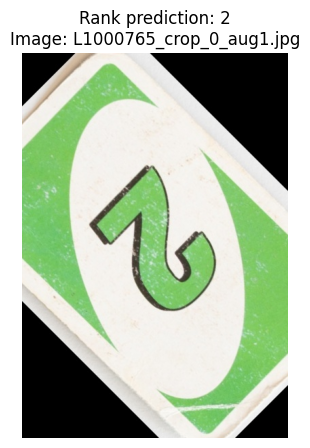

Predicted rank: 2
Rank feature length used at inference: 1796


In [1]:
import os
import numpy as np
import cv2
import joblib
import matplotlib.pyplot as plt
from skimage.feature import hog as skimage_hog
from pathlib import Path

# Paths
PROJECT = Path.cwd().resolve()
RANK_CLF_PATH = os.path.join(PROJECT, "rank_clf.pkl")
RANK_CLASSES_PATH = os.path.join(PROJECT, "rank_classes.npy")
AUG_DIR = os.path.join(PROJECT, "aug")

# Load model + classes
rank_clf = joblib.load(RANK_CLF_PATH)
rank_classes = np.load(RANK_CLASSES_PATH, allow_pickle=True)
print(f"Loaded rank_clf from: {RANK_CLF_PATH}")
print(f"Rank classes ({len(rank_classes)}): {list(rank_classes)}")

IMG_SIZE = 128
FOURIER_COEFFS = 32

def letterbox_cv2(img_bgr, size=IMG_SIZE):
    h, w = img_bgr.shape[:2]
    scale = size / max(h, w)
    new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))
    resized = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((size, size, 3), 128, dtype=np.uint8)
    y0 = (size - new_h) // 2
    x0 = (size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas

def extract_hog_feat(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return skimage_hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
    )

def extract_fourier_feat(img_bgr, n_coeffs=FOURIER_COEFFS):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    bw[:8, :] = 0
    bw[-8:, :] = 0
    bw[:, :8] = 0
    bw[:, -8:] = 0

    contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.zeros(n_coeffs, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)
    pts = cnt[:, 0, :].astype(np.float32)
    if len(pts) < max(10, n_coeffs + 1):
        return np.zeros(n_coeffs, dtype=np.float32)

    z = pts[:, 0] + 1j * pts[:, 1]
    z = z - np.mean(z)
    F = np.fft.fft(z)

    mag = np.abs(F)[1:n_coeffs + 1]
    if len(mag) < n_coeffs:
        mag = np.pad(mag, (0, n_coeffs - len(mag)))

    mag = mag / (mag[0] + 1e-6)
    return mag.astype(np.float32)

def extract_rank_feat(img_bgr):
    hog_vec = extract_hog_feat(img_bgr)
    fd_vec = extract_fourier_feat(img_bgr)
    return np.concatenate([hog_vec, fd_vec])

# Pick one image to test
aug_images = sorted([f for f in os.listdir(AUG_DIR) if f.lower().endswith(".jpg")])
if not aug_images:
    raise FileNotFoundError(f"No .jpg found in {AUG_DIR}")

img_name = aug_images[0]
img_path = os.path.join(AUG_DIR, img_name)
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise FileNotFoundError(f"Cannot read image: {img_path}")

img_lb = letterbox_cv2(img_bgr)
rank_vec = extract_rank_feat(img_lb)
pred_idx = int(rank_clf.predict(rank_vec.reshape(1, -1))[0])
pred_rank = rank_classes[pred_idx]

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title(f"Rank prediction: {pred_rank}\nImage: {img_name}")
plt.axis("off")
plt.show()

print(f"Predicted rank: {pred_rank}")
print(f"Rank feature length used at inference: {rank_vec.shape[0]}")

In [2]:
ref = Path.cwd().resolve()
print(ref.parent)
print(f"Current working directory: {ref}")

/Users/dorianbesson/EDOC/IA/iapr2026do
Current working directory: /Users/dorianbesson/EDOC/IA/iapr2026do/project


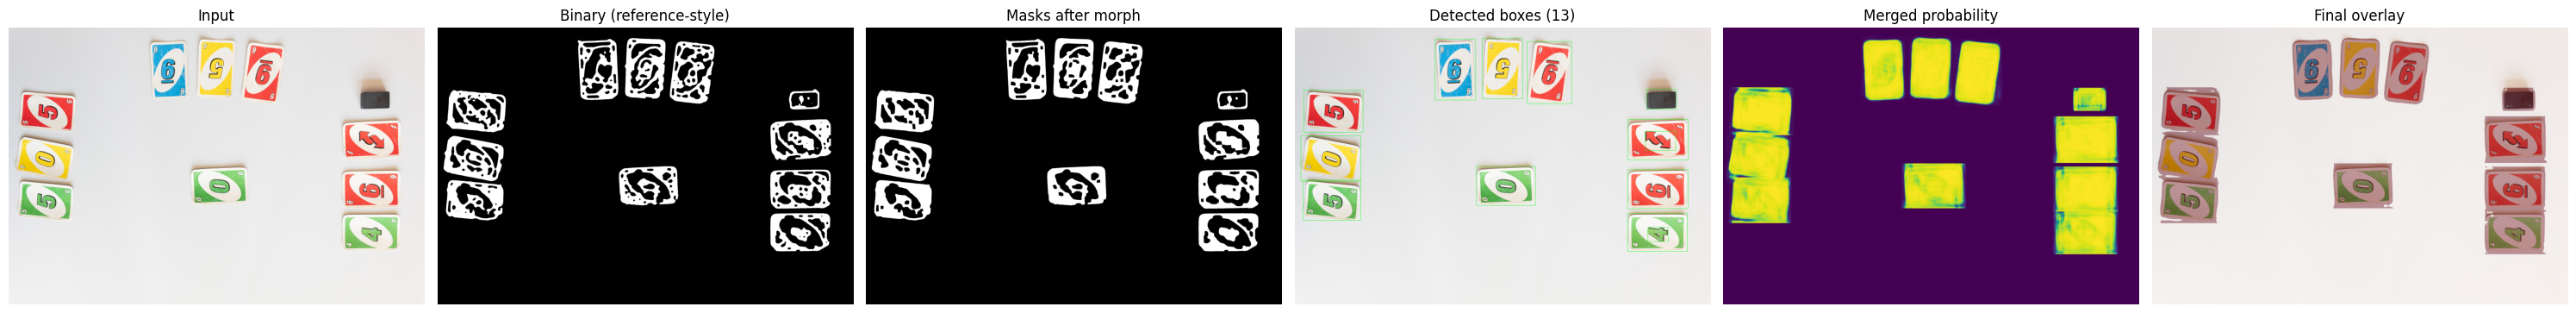

Loaded segmenter model: /Users/dorianbesson/EDOC/IA/iapr2026do/project/segmenter_unet_small.pth
Input image: /Users/dorianbesson/EDOC/IA/iapr2026do/data/iapr-26-uno-vision-challenge/test_images/L1000793.jpg
Detected candidate cards: 13
Foreground pixels (mask>0.5): 2376750


In [3]:
import os
import numpy as np
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

# Paths
PROJECT = Path.cwd().resolve()
TEST_IMG_PATH = PROJECT.parent / "data" / "iapr-26-uno-vision-challenge" / "test_images" / "L1000793.jpg"

SEG_MODEL_CANDIDATES = [
    os.path.join(PROJECT, "segmenter_unet_small.pth"),
    os.path.join(PROJECT, "segment_unet_small.pth"),
]
SEG_MODEL_PATH = next((p for p in SEG_MODEL_CANDIDATES if os.path.isfile(p)), None)
if SEG_MODEL_PATH is None:
    raise FileNotFoundError(f"No segmenter model found in: {SEG_MODEL_CANDIDATES}")

# Same architecture used in training
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


IMG_SIZE = 256


def letterbox_with_meta(img_pil, target_size=IMG_SIZE, fill=255, interpolation=Image.BILINEAR):
    w, h = img_pil.size
    scale = min(target_size / w, target_size / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    img_resized = img_pil.resize((new_w, new_h), interpolation)

    pad_w = target_size - new_w
    pad_h = target_size - new_h
    left = pad_w // 2
    top = pad_h // 2
    right = pad_w - left
    bottom = pad_h - top

    img_lb = TF.pad(img_resized, (left, top, right, bottom), fill=fill)
    meta = {
        "orig_w": w,
        "orig_h": h,
        "new_w": new_w,
        "new_h": new_h,
        "left": left,
        "top": top,
        "target": target_size,
    }
    return img_lb, meta


def unletterbox_mask(mask_lb, meta):
    left, top = meta["left"], meta["top"]
    new_w, new_h = meta["new_w"], meta["new_h"]
    orig_w, orig_h = meta["orig_w"], meta["orig_h"]

    core = mask_lb[top:top + new_h, left:left + new_w]
    core = cv2.resize(core, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
    return core


def detect_card_boxes_reference_style(img_bgr, max_components=24):
    """Detection adapted from reference_cards.ipynb: adaptive threshold + morphology + components."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape[:2]
    img_area = h * w

    adaptive = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        4,
    )
    adaptive = cv2.medianBlur(adaptive, 3)

    binary = adaptive.copy()
    if np.mean(binary == 255) > 0.5:
        binary = cv2.bitwise_not(binary)

    # Same strong morphology style used in reference notebook
    binary = cv2.morphologyEx(binary, cv2.MORPH_DILATE, np.ones((17, 17), np.uint8))
    binary = skeletonize(binary > 0).astype(np.uint8) * 255
    binary = cv2.morphologyEx(binary, cv2.MORPH_DILATE, np.ones((17, 17), np.uint8))
    binary = cv2.medianBlur(binary, 33)

    # Remove tiny contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    min_area = max(2500, int(0.002 * img_area))
    for contour in contours:
        if cv2.contourArea(contour) < min_area:
            cv2.drawContours(binary, [contour], -1, 0, thickness=cv2.FILLED)

    masks = binary.copy()
    masks = cv2.morphologyEx(masks, cv2.MORPH_CLOSE, np.ones((21, 21), np.uint8))
    masks = cv2.morphologyEx(masks, cv2.MORPH_OPEN, np.ones((7, 7), np.uint8))

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(masks, connectivity=8)
    if n_labels <= 1:
        return [(0, 0, w, h)], binary, masks

    areas = stats[1:, cv2.CC_STAT_AREA]
    selected_idx = np.argsort(areas)[::-1][: min(max_components, len(areas))] + 1

    boxes = []
    for label_idx in selected_idx:
        x = int(stats[label_idx, cv2.CC_STAT_LEFT])
        y = int(stats[label_idx, cv2.CC_STAT_TOP])
        bw = int(stats[label_idx, cv2.CC_STAT_WIDTH])
        bh = int(stats[label_idx, cv2.CC_STAT_HEIGHT])

        # Mild shape sanity check only
        ar = bw / max(1, bh)
        area = bw * bh
        if 0.2 <= ar <= 2.5 and area >= min_area:
            boxes.append((x, y, bw, bh))

    if not boxes:
        boxes = [(0, 0, w, h)]

    return boxes, binary, masks


# Load image and model
img_bgr = cv2.imread(TEST_IMG_PATH)
if img_bgr is None:
    raise FileNotFoundError(f"Cannot read test image: {TEST_IMG_PATH}")

H, W = img_bgr.shape[:2]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetSmall().to(device)
model.load_state_dict(torch.load(SEG_MODEL_PATH, map_location=device))
model.eval()

# 1) Detect candidate card crops (reference-style)
boxes, binary_dbg, masks_dbg = detect_card_boxes_reference_style(img_bgr, max_components=24)

# 2) Segment each crop and paste back into global mask
global_prob = np.zeros((H, W), dtype=np.float32)

for (x, y, bw, bh) in boxes:
    margin = int(0.05 * max(bw, bh))
    x0 = max(0, x - margin)
    y0 = max(0, y - margin)
    x1 = min(W, x + bw + margin)
    y1 = min(H, y + bh + margin)

    crop_bgr = img_bgr[y0:y1, x0:x1]
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    crop_pil = Image.fromarray(crop_rgb)

    crop_lb, meta = letterbox_with_meta(crop_pil, IMG_SIZE, fill=255, interpolation=Image.BILINEAR)

    x_t = TF.to_tensor(crop_lb)
    x_t = TF.normalize(x_t, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x_t)
        prob_lb = torch.sigmoid(logits)[0, 0].cpu().numpy()

    prob_crop = unletterbox_mask(prob_lb, meta)
    global_prob[y0:y1, x0:x1] = np.maximum(global_prob[y0:y1, x0:x1], prob_crop)

mask_bin = (global_prob > 0.5).astype(np.uint8)

# Visualize detection + final outputs
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_boxes = img_rgb.copy()
for (x, y, bw, bh) in boxes:
    cv2.rectangle(img_boxes, (x, y), (x + bw, y + bh), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 6, figsize=(30, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(binary_dbg, cmap="gray")
axes[1].set_title("Binary (reference-style)")
axes[1].axis("off")

axes[2].imshow(masks_dbg, cmap="gray")
axes[2].set_title("Masks after morph")
axes[2].axis("off")

axes[3].imshow(img_boxes)
axes[3].set_title(f"Detected boxes ({len(boxes)})")
axes[3].axis("off")

axes[4].imshow(global_prob, cmap="viridis")
axes[4].set_title("Merged probability")
axes[4].axis("off")

axes[5].imshow(img_rgb)
axes[5].imshow(mask_bin, cmap="Reds", alpha=0.4)
axes[5].set_title("Final overlay")
axes[5].axis("off")

plt.tight_layout()
plt.show()

print(f"Loaded segmenter model: {SEG_MODEL_PATH}")
print(f"Input image: {TEST_IMG_PATH}")
print(f"Detected candidate cards: {len(boxes)}")
print(f"Foreground pixels (mask>0.5): {int(mask_bin.sum())}")


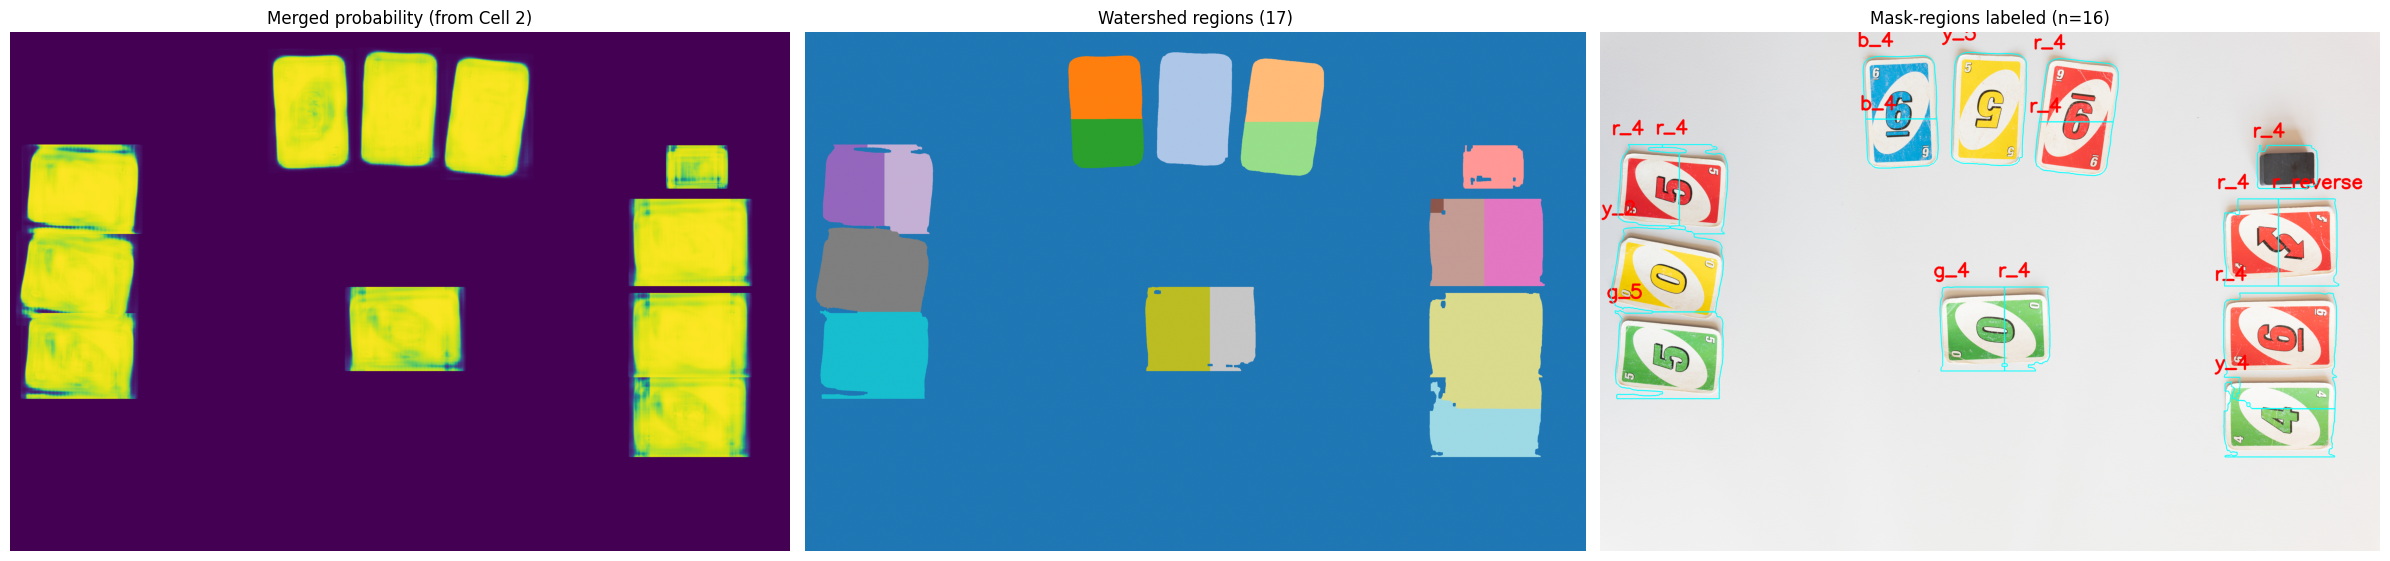

Predictions per watershed region:
  Region 00: (3151,1294)-(3825,1981), area=319544 -> r_4
  Region 01: (33,1386)-(676,1927), area=229869 -> g_5
  Region 02: (10,959)-(679,1484), area=217526 -> y_2
  Region 03: (1756,63)-(2233,735), area=206546 -> y_5
  Region 04: (3154,1750)-(3815,2226), area=143018 -> y_4
  Region 05: (1709,1276)-(2109,1775), area=138737 -> g_4
  Region 06: (3444,824)-(3824,1341), area=133239 -> r_reverse
  Region 07: (59,548)-(440,1038), area=118547 -> r_4
  Region 08: (3163,824)-(3514,1341), area=118011 -> r_4
  Region 09: (1319,96)-(1758,481), area=117035 -> b_4
  Region 10: (2221,109)-(2690,497), area=116733 -> r_4
  Region 11: (284,545)-(692,1075), area=104655 -> r_4
  Region 12: (2200,433)-(2664,773), area=97471 -> r_4
  Region 13: (2040,1276)-(2342,1775), area=94811 -> r_4
  Region 14: (1333,421)-(1764,731), area=88489 -> b_4
  Region 15: (3346,561)-(3705,831), area=63337 -> r_4
Rank model expects 1796 features.
Inference rank feature size used: 1796


In [4]:
import os
import numpy as np
import cv2
import joblib
import matplotlib.pyplot as plt
from skimage.feature import hog as skimage_hog

# Uses variables produced by Cell 2: img_bgr, global_prob
if "img_bgr" not in globals() or "global_prob" not in globals():
    raise RuntimeError("Run Cell 2 first so 'img_bgr' and 'global_prob' are available.")

PROJECT = Path.cwd().resolve()
COLOR_CLF_PATH = PROJECT / "color_clf.pkl"
RANK_CLF_PATH = PROJECT / "rank_clf.pkl"
COLOR_CLASSES_PATH = PROJECT / "color_classes.npy"
RANK_CLASSES_PATH = PROJECT / "rank_classes.npy"
    
color_clf = joblib.load(COLOR_CLF_PATH)
rank_clf = joblib.load(RANK_CLF_PATH)
color_classes = np.load(COLOR_CLASSES_PATH, allow_pickle=True)
rank_classes = np.load(RANK_CLASSES_PATH, allow_pickle=True)

IMG_SIZE = 128
LABEL_SCALE = 3.25
LABEL_THICKNESS = 10
HIGH_PROB_THRESH = 0.75
CARD_MIN_DIST = 60
FOURIER_COEFFS = 32

def letterbox_cv2(img_bgr, size=IMG_SIZE):
    h, w = img_bgr.shape[:2]
    scale = size / max(h, w)
    new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))
    resized = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((size, size, 3), 128, dtype=np.uint8)
    y0 = (size - new_h) // 2
    x0 = (size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas

def extract_color_feat(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = (hsv[:, :, 1] > 40).astype(np.uint8) * 255
    h_hist = cv2.calcHist([hsv], [0], mask, [32], [0, 180]).flatten()
    s_hist = cv2.calcHist([hsv], [1], mask, [16], [0, 256]).flatten()
    feat = np.concatenate([h_hist, s_hist])
    return feat / (feat.sum() + 1e-6)

def extract_hog_feat(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return skimage_hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
    )

def extract_fourier_feat(img_bgr, n_coeffs=FOURIER_COEFFS):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    bw[:8, :] = 0
    bw[-8:, :] = 0
    bw[:, :8] = 0
    bw[:, -8:] = 0

    contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.zeros(n_coeffs, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)
    pts = cnt[:, 0, :].astype(np.float32)
    if len(pts) < max(10, n_coeffs + 1):
        return np.zeros(n_coeffs, dtype=np.float32)

    z = pts[:, 0] + 1j * pts[:, 1]
    z = z - np.mean(z)
    F = np.fft.fft(z)

    mag = np.abs(F)[1:n_coeffs + 1]
    if len(mag) < n_coeffs:
        mag = np.pad(mag, (0, n_coeffs - len(mag)))

    mag = mag / (mag[0] + 1e-6)
    return mag.astype(np.float32)

def extract_rank_feat(img_bgr):
    hog_vec = extract_hog_feat(img_bgr)
    fd_vec = extract_fourier_feat(img_bgr)
    return np.concatenate([hog_vec, fd_vec])

# 1) Build high-confidence mask from global probability
high_mask = (global_prob >= HIGH_PROB_THRESH).astype(np.uint8)
high_mask = cv2.morphologyEx(high_mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
high_mask = cv2.morphologyEx(high_mask, cv2.MORPH_CLOSE, np.ones((11, 11), np.uint8))

# 2) Watershed to split touching/stacked cards
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

distance = ndi.distance_transform_edt(high_mask)
coords = peak_local_max(distance, min_distance=CARD_MIN_DIST, labels=high_mask)
peak_mask = np.zeros(distance.shape, dtype=bool)
if coords.size > 0:
    peak_mask[tuple(coords.T)] = True
markers, _ = ndi.label(peak_mask)
if markers.max() == 0:
    markers = ndi.label(high_mask)[0]
ws_labels = watershed(-distance, markers, mask=high_mask)

# 3) Collect one region per watershed label
img_h, img_w = high_mask.shape
img_area = img_h * img_w
min_area = max(1200, int(0.0015 * img_area))

regions = []
for lab in range(1, ws_labels.max() + 1):
    comp = (ws_labels == lab).astype(np.uint8)
    area = int(comp.sum())
    if area < min_area:
        continue
    ys, xs = np.where(comp)
    x, y = int(xs.min()), int(ys.min())
    w, h = int(xs.max()) - x + 1, int(ys.max()) - y + 1
    regions.append((x, y, w, h, area, lab))

regions.sort(key=lambda r: r[4], reverse=True)

# 4) Classify each watershed region
vis = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
pred_rows = []

for i, (x, y, w, h, area, lab) in enumerate(regions):
    margin = int(0.08 * max(w, h))
    x0 = max(0, x - margin)
    y0 = max(0, y - margin)
    x1 = min(img_bgr.shape[1], x + w + margin)
    y1 = min(img_bgr.shape[0], y + h + margin)

    crop = img_bgr[y0:y1, x0:x1]
    crop_lb = letterbox_cv2(crop)

    color_vec = extract_color_feat(crop_lb).reshape(1, -1)
    rank_vec = extract_rank_feat(crop_lb).reshape(1, -1)

    color_idx = int(color_clf.predict(color_vec)[0])
    rank_idx = int(rank_clf.predict(rank_vec)[0])

    color_name = str(color_classes[color_idx])
    rank_name = str(rank_classes[rank_idx])

    if rank_name in ("wild", "draw_4"):
        label = rank_name
    elif color_name == "__special__":
        label = rank_name
    else:
        label = f"{color_name}_{rank_name}"

    pred_rows.append((i, x0, y0, x1, y1, area, label))

    comp_mask = (ws_labels == lab).astype(np.uint8) * 255
    contours, _ = cv2.findContours(comp_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(vis, contours, -1, (0, 255, 255), 3)

    y_text = y0 - 20 if y0 - 20 > 20 else y0 + 50
    cv2.putText(
        vis,
        label,
        (x0, y_text),
        cv2.FONT_HERSHEY_SIMPLEX,
        LABEL_SCALE,
        (255, 0, 0),
        LABEL_THICKNESS,
        cv2.LINE_AA,
    )

# 5) Show outputs
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

axes[0].imshow(global_prob, cmap="viridis")
axes[0].set_title("Merged probability (from Cell 2)")
axes[0].axis("off")

axes[1].imshow(ws_labels, cmap="tab20")
axes[1].set_title(f"Watershed regions ({ws_labels.max()})")
axes[1].axis("off")

axes[2].imshow(vis)
axes[2].set_title(f"Mask-regions labeled (n={len(pred_rows)})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Predictions per watershed region:")
for i, x0, y0, x1, y1, area, label in pred_rows:
    print(f"  Region {i:02d}: ({x0},{y0})-({x1},{y1}), area={area} -> {label}")

# verify feature size expected by model
if hasattr(rank_clf, "n_features_in_"):
    print(f"Rank model expects {rank_clf.n_features_in_} features.")
    if pred_rows:
        print(f"Inference rank feature size used: {rank_vec.shape[1]}")